<h1>Consumer Sentiment Classification</h1>

<h2>Introduction</h2>

<h2>Dataset</h2>
Please Download the
<a href='https://www.kaggle.com/datasets/selener/consumer-complaint-database'>Dataset</a>
<p>Please download the : lid.176.bin model for fasttext at: https://fasttext.cc/docs/en/language-identification.html, and place it in the same folder as this file</p>
<p>Features</p>
<ul>
<li>Date received - The date when the consumer complaint was received.</li>
<li>Product - The specific financial product or service associated with the complaint.</li>
<li>Sub-product - Further sub-categorization of the product or service, if applicable.</li>
<li>Issue - The main issue or problem described in the consumer complaint.</li>
<li>Sub-issue - Additional details or sub-category related to the main issue.</li>
<li>Consumer complaint narrative - The text description provided by the consumer detailing their complaint.</li>
<li>Company public response	The response or statement issued by the company regarding the complaint.</li>
<li>Company	The name of the company being complained about.</li>
<li>State	The state where the consumer resides.</li>
<li>ZIP code	The ZIP code of the consumer's location.</li>
<li>Tags	Any additional tags or labels associated with the complaint.</li>
<li>Consumer consent provided? - Indicates whether the consumer provided consent for their complaint to be published.</li>
<li>Submitted via - The channel or method through which the complaint was submitted.</li>
<li>Date sent to company - The date when the complaint was sent to the company for response.</li>
<li>Company response to consumer - The company's response or resolution to the consumer's complaint.</li>
<li>Timely response? - Indicates whether the company provided a timely response to the complaint.</li>
<li>Consumer disputed? - Indicates whether the consumer disputed the company's response.</li>
<li>Complaint ID - A unique identifier assigned to each complaint.</li>
</ul>

<p>
This Notebook will address a Medical Aid Scheme’s request to conduct a text data analysis to obtain the main areas of concern and analyse customer sentiments using a dataset of my own so they can have a general idea of the efficacy of the method to probably implement a similar model for the negative reviews they have been receiving.
</p>

<p>The fasttext-wheel model  was intstalled due to instabilities to the normal fasttext found on Python and it is instable with some versions of numpy hence why, I am installing a specific version of it.</p>

In [1]:
!pip install --upgrade nltk fasttext-wheel numpy==1.26.4 vaderSentiment pyLDAvis

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Alexi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
#-------------------------------------------------------------------------------
# Data Manipulation Libraries
#-------------------------------------------------------------------------------
#Pandas : Used for data loading, manipulation, cleaning, and tabular data structures 
import pandas as pd
# Regular Expression: Pattern matching and text cleaning
import re
# For efficient counting and frequency analysis
from collections import Counter
# Progress bars for pandas long-running operations
from tqdm import tqdm

#-------------------------------------------------------------------------------
# Data Visualization Libraries
#-------------------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pyLDAvis

#-------------------------------------------------------------------------------
# Mathematical and Statistical Computing Libraries
#-------------------------------------------------------------------------------
import numpy as np
from scipy.stats import pearsonr

#-------------------------------------------------------------------------------
# Natural Language Processing Libraries
#-------------------------------------------------------------------------------
# NLTK: Natural Language Toolkit
import nltk
# English dictionary words and stopwords
from nltk.corpus import words, stopwords
# Tokenize
from nltk.tokenize import word_tokenize
# N-Gram generation
from nltk.util import ngrams
# Language Detection
import fasttext
# Lemmatization
from nltk.stem import WordNetLemmatizer
# VADER sentiment analyzer
from nltk.sentiment import SentimentIntensityAnalyzer
# Delete
from textblob import TextBlob
# VADER negation list
from vaderSentiment.vaderSentiment import NEGATE

#-------------------------------------------------------------------------------
# Feature Extraction and Teext Vectorization
#-------------------------------------------------------------------------------
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction import text 

#-------------------------------------------------------------------------------
# Topic Modelling
#-------------------------------------------------------------------------------
from sklearn.decomposition import LatentDirichletAllocation

#-------------------------------------------------------------------------------
# Machine Learning Models for Sentiment Classification.
#-------------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

#-------------------------------------------------------------------------------
# Model Evaluation Metrics Libraries
#-------------------------------------------------------------------------------
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix

#-------------------------------------------------------------------------------
# Model Selection and ValidationLibraries
#-------------------------------------------------------------------------------
# GridSearchCV: Hyperparameter tuning using cross-validation
# StratifiedKFold: Preserves class distribution across folds
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# Traain-Test Split: Splits dataset into training and testing subsets.
from sklearn.model_selection import train_test_split

#-------------------------------------------------------------------------------
# Pipeline Management
#-------------------------------------------------------------------------------
from sklearn.pipeline import Pipeline

#-------------------------------------------------------------------------------
# Notebook Visualization Settings
#-------------------------------------------------------------------------------
# Enables inline plotting in Jupyter notebooks.
%matplotlib inline

# Sets Seaborn dark theme for cleaner plots.
sns.set_style("darkgrid")
# Sets default color palette
sns.set_palette('husl',8)

In [3]:
# Read dataset
df = pd.read_csv("rows.csv", low_memory=False)

In [4]:
# Shows top 5 rows
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460


<h2>Exploratory Data Analysis</h2>

<h3>Cleaning</h3>

In [5]:
# Show dataset shape
df.shape

(1282355, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 18 columns):
 #   Column                        Non-Null Count    Dtype 
---  ------                        --------------    ----- 
 0   Date received                 1282355 non-null  object
 1   Product                       1282355 non-null  object
 2   Sub-product                   1047189 non-null  object
 3   Issue                         1282355 non-null  object
 4   Sub-issue                     751169 non-null   object
 5   Consumer complaint narrative  383564 non-null   object
 6   Company public response       449082 non-null   object
 7   Company                       1282355 non-null  object
 8   State                         1262955 non-null  object
 9   ZIP code                      1167057 non-null  object
 10  Tags                          175643 non-null   object
 11  Consumer consent provided?    690654 non-null   object
 12  Submitted via                 1282355 non-

<p>The variables type are correct, all of them are object.</p>

In [7]:
df.isnull().sum()

Date received                         0
Product                               0
Sub-product                      235166
Issue                                 0
Sub-issue                        531186
Consumer complaint narrative     898791
Company public response          833273
Company                               0
State                             19400
ZIP code                         115298
Tags                            1106712
Consumer consent provided?       591701
Submitted via                         0
Date sent to company                  0
Company response to consumer          7
Timely response?                      0
Consumer disputed?               513854
Complaint ID                          0
dtype: int64

In [8]:
df.isna().sum()

Date received                         0
Product                               0
Sub-product                      235166
Issue                                 0
Sub-issue                        531186
Consumer complaint narrative     898791
Company public response          833273
Company                               0
State                             19400
ZIP code                         115298
Tags                            1106712
Consumer consent provided?       591701
Submitted via                         0
Date sent to company                  0
Company response to consumer          7
Timely response?                      0
Consumer disputed?               513854
Complaint ID                          0
dtype: int64

<p>No distinction between the "nan" or "invalid" values, and there are many</p>

In [9]:
# Shows the sum duplicated rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


<p>Fortunately there are no duplicates, meaning only the missing values will be deleted.</p>

In [10]:
# Removes "nan" words 
df = df.dropna(subset=['Consumer complaint narrative'])

In [11]:
# Removes other variables except complaint narrative
df = df[['Consumer complaint narrative']]
df.head()

,Consumer complaint narrative
29904,The Summer of XX/XX/2018 I was denied a mortga...
30629,There are many mistakes appear in my report wi...
30735,There are many mistakes appear in my report wi...
30795,There are many mistakes appear in my report wi...
30807,There are many mistakes appear in my report wi...


<p>The XX here indicate redacted data, probable, personal infromation, dates, location, numbers and so on, they will have to be removed.</p>

In [12]:
# Shape after removing most data
df.shape

(383564, 1)

<p>After removing the invalid data around 32% of it reamins, fortunately it is still enough for the analysis.</p>

In [13]:
# Displaying and counting words with les than 21 characters
df2 = df[df['Consumer complaint narrative'].str.len()<=20]
print(df2.shape)
df2.head(10)

(171, 1)


,Consumer complaint narrative
56284,Needs to be removed
56312,Needs to be removed
84752,FTC NOT MINE REMOVE
99833,They did not respond
104704,Account is fraud
104727,Account is fraud
104785,Account is fraud
105162,Account fraud
114433,Account is not mine
132647,Debt is not mine.


<p>Checking if the complaints with short length are valid or not. They are.</p>

In [14]:
# Creating back-up without cleaning, will use it for statistics analysis
backup_df = df.copy()

In [15]:
# Text Filter Part 1
df['Consumer complaint narrative'] = (
    df['Consumer complaint narrative']
    .str.replace(r'[^\x00-\x7F+]',' ', regex=True) # Removes emoji
    .str.replace(r'http\S+|www\S+',' ', regex=True) # removes url
    .str.replace(r'\s+',' ', regex=True) # Remove extra white space
    .str.strip()
)

In [16]:
# Text Filter Part 2
df['Consumer complaint narrative'] = (
    df['Consumer complaint narrative']
    .str.lower()
    .str.replace(r'\bx+\b',' ', regex=True) # replace sequence of  'x'
    .str.replace(r'\s+',' ', regex=True) # Remove extra white space
    .str.strip()
)

In [17]:
# Text Filter Part 3
df['Consumer complaint narrative'] = (
    df['Consumer complaint narrative']
    .str.replace(r'\d+', ' ', regex=True) # Remove digits
    .str.replace(r'\s+',' ', regex=True) # Remove extra white space
    .str.strip()
)


In [18]:
# Text Filter Part 4
df['Consumer complaint narrative'] = (
    df['Consumer complaint narrative']
    .str.replace(r'[^a-zA-Z\[\]\s]',' ', regex=True) # Remove special character and numbers
    .str.replace(r'\s+',' ', regex=True) # Remove extra white space
    .str.strip()
)

<p>
The data cleaning process was not aimless and had a specific objective besides cleaning missing and duplicate data, and it included the removal of:
•	Emoji;

•	Url (e.g. https://somethi...);

•	Sequence of “x”, which indicates redacted data;

•	Numbers;

•	Special characters (e.g., £, &, @, etc.);

•	The extra white space left when removing everything on this list.

All of this data was removed to improve data quality and ensure the exploratory data analysis explained the real intent of the analysis, which is to analyse complaints, and it also reduces the computational power required to perform any analysis and build the models.

</p>

In [19]:
# Top 5 narratives after claning text
df.head()

,Consumer complaint narrative
29904,the summer of i was denied a mortgage loan due...
30629,there are many mistakes appear in my report wi...
30735,there are many mistakes appear in my report wi...
30795,there are many mistakes appear in my report wi...
30807,there are many mistakes appear in my report wi...


In [20]:
# Checking for empty rows
empty_rows = df[df['Consumer complaint narrative'].str.strip() == '']
print(f"Number of empty rows: {len(empty_rows)}")

Number of empty rows: 4


<h4>Handling Non-English Words</h4>

In [21]:
#Accessing pre-built model that detects languages
model = fasttext.load_model('lid.176.bin')
def detect_language(txt):
        pred = model.predict(str(txt).replace('\n', ' '))
        return pred[0][0].replace('__label__','')

In [22]:
# Applting the model and checking the language within the text 
df['lan'] = df['Consumer complaint narrative'].apply(detect_language)
df['lan'].value_counts()

lan
en     383545
fr          9
de          2
es          1
it          1
hu          1
sr          1
ca          1
sv          1
ceb         1
sq          1
Name: count, dtype: int64

In [23]:
# Checking if the model can predict engligh well
model.predict("This is a complaint in english")

(('__label__en',), array([0.94983351]))

In [24]:
# Checking if model can predict another language will (Portuguese)
model.predict("Esta é uma reclamação em portugues")

(('__label__pt',), array([1.00004935]))

<p>The fasttext model can predict both english and portuguese well, then I will believe on its judgement remove the rows with said data.</p>

In [25]:
# Displaying suposed texts with french
df[df['lan'] == 'fr']['Consumer complaint narrative'].values

array(['debt fraudulent', 'fraudulent account xxxx fraudulent inquires',
       'federal tax lien docket federal tax lien docket federal tax lien docket state tax lien docket state tax lien docket',
       'fraudulent accounts', 'fraudulent accounts',
       'fraudulent accounts', 'fraudulent account xxxx',
       'fraude accounts', 'fradulent'], dtype=object)

In [26]:
# Passing rows with only engish 
df = df[df['lan'] == 'en']
# Counting the languages within the lan variable to check if other languages where removed
df['lan'].value_counts()

lan
en    383545
Name: count, dtype: int64

In [27]:
# Droping column lan
df = df.drop('lan',axis=1)

<p>There will not be another language related analysis, the column can be dropped.</p>

In [28]:
# Filter empty rows
df = df[df['Consumer complaint narrative'].str.strip() != '']

In [29]:
# Removing empty wors and checking them
empty_rows = df[df['Consumer complaint narrative'].str.strip() == '']
print(f"Number of empty rows: {len(empty_rows)}")

Number of empty rows: 0


<h3>Text Statistics</h3>

In [30]:
# Obtaning text length
text_length = (backup_df['Consumer complaint narrative'].str.len())

In [31]:
print(f'Character Length Statistics')
print(f'Mean : {text_length.mean():.2f}')
print(f'Median : {text_length.median():.2f}')
print(f'Min : {text_length.min():.2f}')
print(f'Max : {text_length.max():.2f}')
print(f'Standard Deviation : {text_length.std():.2f}')

Character Length Statistics
Mean : 1082.01
Median : 744.00
Min : 5.00
Max : 31735.00
Standard Deviation : 1173.51


<p>
Since the mean is higher than the median, it indicates the dataset’s text length is right-skewed, meaning most complaints are relatively moderate in size, and a small number of them have long complaints.
</p>

In [32]:
# Function to count words
def count_words(df, chunk_size=5000):
    counts=[]
    for i in range(0, len(df), chunk_size):
        chunk = df.iloc[i:i + chunk_size]
        chunk_counts = chunk.str.count(' ') + 1
        counts.append(chunk_counts)
    return pd.concat(counts)

word_counts = count_words(backup_df['Consumer complaint narrative'])

In [33]:
print(f'Word Count Statistics')
print(f'Mean : {word_counts.mean():.2f}')
print(f'Median : {word_counts.median():.2f}')
print(f'Min : {word_counts.min():.2f}')
print(f'Max : {word_counts.max():.2f}')
print(f'Standard Deviation : {word_counts.std():.2f}')

Word Count Statistics
Mean : 198.61
Median : 137.00
Min : 1.00
Max : 6320.00
Standard Deviation : 213.58


<p>
Most complaints are short to medium length, with around 100 to 200 words, and as mentioned above, there is a small number of outliers with very long words.
</p>

In [34]:
# Using nltk toolkit to count sentences.
nltk.download('punkt')
nltk.download('punkt_tab')
tqdm.pandas()
sentence_counts = backup_df['Consumer complaint narrative'].progress_apply(lambda x: len(nltk.sent_tokenize(str(x))))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Alexi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Alexi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
100%|██████████| 383564/383564 [01:07<00:00, 5650.17it/s]


In [35]:
print(f'Sentence Count Statistics')
print(f'Mean : {sentence_counts.mean():.2f}')
print(f'Median : {sentence_counts.median():.2f}')
print(f'Min : {sentence_counts.min():.2f}')
print(f'Max : {sentence_counts.max():.2f}')
print(f'Standard Deviation : {sentence_counts.std():.2f}')


Sentence Count Statistics
Mean : 9.43
Median : 7.00
Min : 1.00
Max : 290.00
Standard Deviation : 9.68


<p>
This indicates that complaints consist of a small number of sentences, and that small outliers containing a high number of words are repeated.
</p>

<h3>Tokenisation</h3>

In [36]:
# Using nltk toolkit to tokenize complaints
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Functions to tokenize text
def tokenise(df, chunk_size=10000):
    all_tokens = []
    # Loops through the dataset in chunks to reduce memory use.
    for i in range(0, len(df), chunk_size):
        chunk = df.iloc[i:i+chunk_size]
        # Tokenize complaints narrative
        tokens = chunk['Consumer complaint narrative'].apply(word_tokenize)
        all_tokens.extend(tokens)

        if(i + chunk_size) %50000 ==0:
            print(f'Processed {i + chunk_size:,} complaints')

    return all_tokens

tqdm.pandas()
df['word_tokens'] = tokenise(df)

Processed 50,000 complaints
Processed 100,000 complaints
Processed 150,000 complaints
Processed 200,000 complaints
Processed 250,000 complaints
Processed 300,000 complaints
Processed 350,000 complaints


In [37]:
df.head()

,Consumer complaint narrative,word_tokens
29904,the summer of i was denied a mortgage loan due...,"[the, summer, of, i, was, denied, a, mortgage,..."
30629,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r..."
30735,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r..."
30795,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r..."
30807,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r..."


<h3>Lemmatization</h3>

In [38]:
# Lemmatization
tqdm.pandas()
nltk.download('wordnet',quiet=True)

def lemm(tokens):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token) for token in tokens]

df['lemmatized_tokens'] = df['word_tokens'].progress_apply(lemm)

100%|██████████| 383541/383541 [04:18<00:00, 1483.06it/s]


In [39]:
df.head()

,Consumer complaint narrative,word_tokens,lemmatized_tokens
29904,the summer of i was denied a mortgage loan due...,"[the, summer, of, i, was, denied, a, mortgage,...","[the, summer, of, i, wa, denied, a, mortgage, ..."
30629,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re..."
30735,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re..."
30795,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re..."
30807,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re..."


<p>Tokenisation was applied to split each complaint into individual words (tokens). This process converts unstructured text into smaller units that can be analysed computationally, and it is the foundation of the next steps. </p>

<h3>Removing Stop Words</h3>

In [40]:
# Removing Stop Words
tqdm.pandas()

custom_stopwords = list(text.ENGLISH_STOP_WORDS)
#custom_stopwords.extend(['[redacted]'])

def remove_stopwords_from_tokens(tokens):
    return [token for token in tokens if token not in custom_stopwords]

df['filtered_tokens'] = df['lemmatized_tokens'].progress_apply(remove_stopwords_from_tokens)

100%|██████████| 383541/383541 [02:59<00:00, 2136.01it/s]


In [41]:
df.head()

,Consumer complaint narrative,word_tokens,lemmatized_tokens,filtered_tokens
29904,the summer of i was denied a mortgage loan due...,"[the, summer, of, i, was, denied, a, mortgage,...","[the, summer, of, i, wa, denied, a, mortgage, ...","[summer, wa, denied, mortgage, loan, charge, c..."
30629,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]"
30735,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]"
30795,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]"
30807,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]"


<p>Common English stop words such as “the, “is”, “and” “of” carry little semantic value and were removed from the text, and by doing so, it helps to reduce noise from the dataset and enables the analysis to focus on terms that contribute more to the themes and customer sentiments.
</p>

In [42]:
print(f'Before stopword removal: {len(df['lemmatized_tokens'].iloc[0])} tokens')
print(f'After stopword removal: {len(df['filtered_tokens'].iloc[0])} tokens')

Before stopword removal: 120 tokens
After stopword removal: 55 tokens


Around 45% of the tokens were from stop words.This will increase the analysis reliability, model performance and reduce the computational power needed for it.

<h3>Handling Negation</h3>

In [43]:
# Handling Negations
negation_words = set(NEGATE)
def handle_negation(tokens, window=3):
    #Tokenizing
    result =[]
    negate = False
    remaining =0

    for token in tokens:
        if token in negation_words:
            result.append(token)
            negate= True
            remaining = window
            continue
        if negate and remaining >0:
            result.append(f'NOT_{token}')
            remaining -=1
            
            if remaining ==0:
                negate=False
        else:
            result.append(token)

    return result

tqdm.pandas()
df['negation_tokens'] = df['filtered_tokens'].progress_apply(handle_negation)

100%|██████████| 383541/383541 [00:05<00:00, 75207.55it/s]


In [44]:
# Create a string version for easy manipulation
df['negation_text'] = df['negation_tokens'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')

In [45]:
# Checking for _NOT patterns
df2 = df.copy()
df2['has_negation'] = df2['negation_text'].str.contains('NOT_', na=False)
total = len(df2)
with_negation = df2['has_negation'].sum()
wihout_negation = total - with_negation
print(f'Complaints with negation {with_negation:,}')
print(f'Complaints without negation {wihout_negation:,}')

Complaints with negation 30,807
Complaints without negation 352,734


<p>Negation handling was applied to preserve the meaning of phrases containing terms such as not, never, and no. Such a step is necessary to allow the computer to differentiate the meaning of words such as “go” and “do not go”, and to do it, a negation window was implemented to “NOT_” to some words, meaning “do not go” would become “do NOT_go”. This allows sentiment analysis and machine learning models to better capture the true meaning of words. After handling the negation complaints with negation, 30,807 were found.
</p>

In [46]:
# Creating a sample with 10000 since for some graphs and analysis
df_sample = df.sample(10000, random_state=42)

<h3>Top Words</h3>

In [47]:
# Function to get the top token freqency
def get_word_frequencies_chunked(df, token_column, chunk_size=5000, top_k=50):

    word_counter = Counter()
    total_chunks = (len(df) + chunk_size -1) // chunk_size
    
    print(f'Processing {len(df):,}, rows in {total_chunks}...')

    for i in tqdm(range(0, len(df), chunk_size), desc='Processing chunks', total=total_chunks):
        chunk = df.iloc[i:i+chunk_size]
        # Process each token in the chunk
        for tokens in chunk[token_column]:
            if isinstance(tokens, list):
                # Filter out short tokens
                filtered = [token for token in tokens if len(token) > 1]
                word_counter.update(filtered)

    return word_counter.most_common(top_k)
top_words = get_word_frequencies_chunked(df, 'negation_tokens', top_k=50)

Processing 383,541, rows in 77...


Processing chunks: 100%|██████████| 77/77 [00:09<00:00,  8.05it/s]


In [48]:
df.head()

,Consumer complaint narrative,word_tokens,lemmatized_tokens,filtered_tokens,negation_tokens,negation_text
29904,the summer of i was denied a mortgage loan due...,"[the, summer, of, i, was, denied, a, mortgage,...","[the, summer, of, i, wa, denied, a, mortgage, ...","[summer, wa, denied, mortgage, loan, charge, c...","[summer, wa, denied, mortgage, loan, charge, c...",summer wa denied mortgage loan charge credit c...
30629,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]","[mistake, appear, report, understanding]",mistake appear report understanding
30735,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]","[mistake, appear, report, understanding]",mistake appear report understanding
30795,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]","[mistake, appear, report, understanding]",mistake appear report understanding
30807,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]","[mistake, appear, report, understanding]",mistake appear report understanding


In [49]:
print('The top 50 most common words:')
for i, (word, count) in enumerate(top_words, 1):
    print(f'{i:3}. {word:15}: {count:>8}')

The top 50 most common words:
  1. wa             :   999653
  2. credit         :   587137
  3. account        :   584367
  4. payment        :   403596
  5. loan           :   311131
  6. report         :   287958
  7. time           :   235671
  8. information    :   233197
  9. ha             :   232184
 10. debt           :   217294
 11. bank           :   214840
 12. company        :   206775
 13. did            :   204439
 14. told           :   199581
 15. received       :   184980
 16. card           :   182895
 17. day            :   169892
 18. letter         :   167673
 19. called         :   162235
 20. month          :   151035
 21. sent           :   143466
 22. pay            :   138533
 23. year           :   137395
 24. mortgage       :   134852
 25. number         :   127928
 26. paid           :   127556
 27. reporting      :   122021
 28. said           :   121920
 29. collection     :   120143
 30. phone          :   111450
 31. balance        :   107193
 32. mone

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

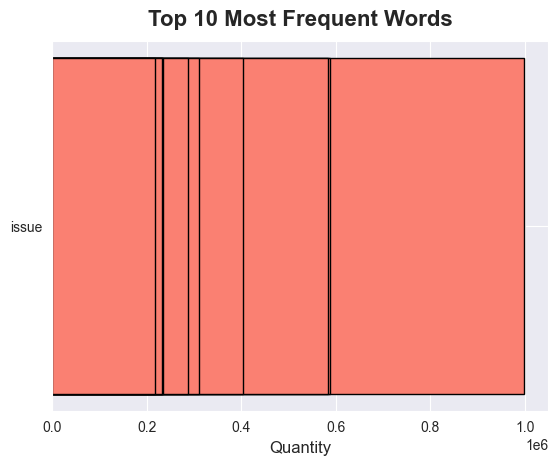

In [50]:
# Get top 10 words and quantity
words, counts = zip(*top_words[:10])
# Create  barh plot
figsize=(12,8)
plt.barh(word,counts, color='salmon', edgecolor='black', linewidth=1)
plt.xlabel('Quantity', fontsize=12)
plt.title('Top 10 Most Frequent Words', fontsize=16,fontweight='bold',y=1.02)
plt.tight_layout

<p>
The top words bar plot shows that was, credit, account, payment and loan are among the most repeated words across all, with was being the first most repeated word, indicating that most consumers were indeed reporting personal issues 
</p>

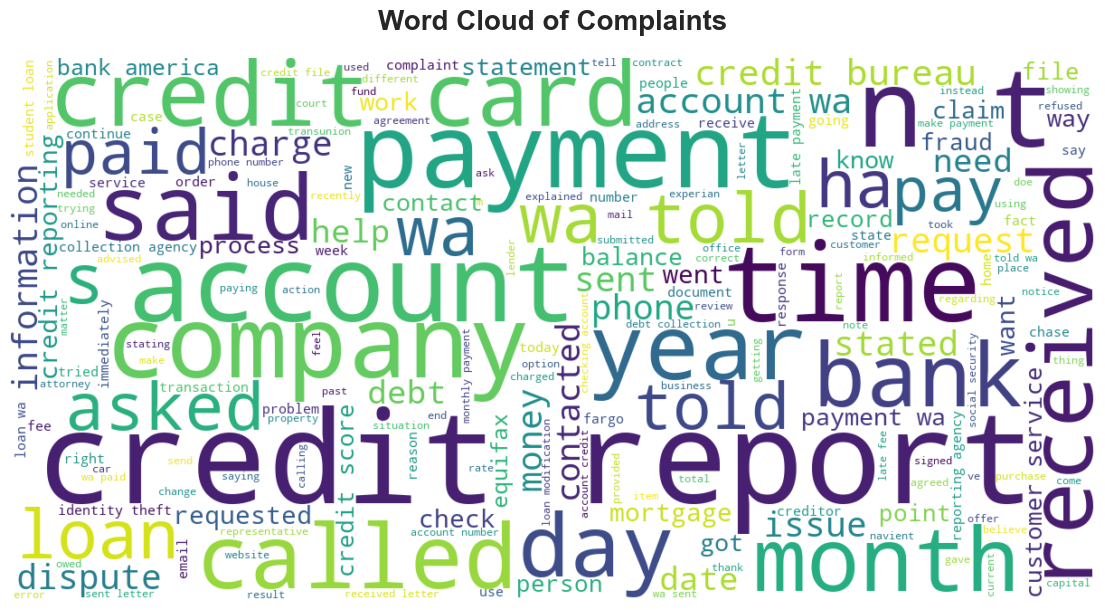

In [51]:
#Create word cloud from all tokens
def create_wordcloud_from_tokens(token_column, title='Word Cloud of Complaints', max_words=200, width=1200, height=600):

    all_text = ' '.join([token for tokens in token_column for token in tokens])
    # Create word cloud
    wordcloud = WordCloud(width=width,
                          height=height,
                          background_color='white',
                          max_words=max_words,
                          colormap='viridis',
                          contour_width=1,
                          contour_color='steelblue',
                          random_state=42).generate(all_text)
    # Display word cloud
    plt.figure(figsize=(14,8))
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20, fontweight='bold', pad=20)
    plt.show()
    return wordcloud

# Create word cloud from negation tokens
wordloud = create_wordcloud_from_tokens(df_sample['negation_tokens'])

<p>
he word clouds show the top 200 words that were repeated most, and it is also possible to visualise that credit, time, report, payment, account, company, and received are among the most repeated words across complaints.</p>

<h3>Sentiment Classification</h3>

In [52]:
# Sentiment Classification
tqdm.pandas()
#df_sample = df['Consumer complaint narrative'].sample(50000, random_state=42)
# Common Positive and Negative words
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()
# Get sentiment scores
df['vader_scores'] = df['negation_text'].progress_apply(sia.polarity_scores)

100%|██████████| 383541/383541 [05:34<00:00, 1145.82it/s]


In [53]:
# Calculates sentiment_compound based on vader scores
tqdm.pandas()
df['sentiment_compound'] = df['vader_scores'].progress_apply(lambda x: x['compound'])

100%|██████████| 383541/383541 [00:00<00:00, 1052009.41it/s]


In [54]:
# Applis  threshold on the sentiment compound to classify emotion
df['sentiment_class'] = pd.cut(df['sentiment_compound'], bins=[-1, -0.05, 0.05, 1], labels=['Negative', 'Neutral', 'Positive'])

In [55]:
df.head()

,Consumer complaint narrative,word_tokens,lemmatized_tokens,filtered_tokens,negation_tokens,negation_text,vader_scores,sentiment_compound,sentiment_class
29904,the summer of i was denied a mortgage loan due...,"[the, summer, of, i, was, denied, a, mortgage,...","[the, summer, of, i, wa, denied, a, mortgage, ...","[summer, wa, denied, mortgage, loan, charge, c...","[summer, wa, denied, mortgage, loan, charge, c...",summer wa denied mortgage loan charge credit c...,"{'neg': 0.242, 'neu': 0.551, 'pos': 0.207, 'co...",-0.3818,Negative
30629,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]","[mistake, appear, report, understanding]",mistake appear report understanding,"{'neg': 0.444, 'neu': 0.556, 'pos': 0.0, 'comp...",-0.3400,Negative
30735,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]","[mistake, appear, report, understanding]",mistake appear report understanding,"{'neg': 0.444, 'neu': 0.556, 'pos': 0.0, 'comp...",-0.3400,Negative
30795,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]","[mistake, appear, report, understanding]",mistake appear report understanding,"{'neg': 0.444, 'neu': 0.556, 'pos': 0.0, 'comp...",-0.3400,Negative
30807,there are many mistakes appear in my report wi...,"[there, are, many, mistakes, appear, in, my, r...","[there, are, many, mistake, appear, in, my, re...","[mistake, appear, report, understanding]","[mistake, appear, report, understanding]",mistake appear report understanding,"{'neg': 0.444, 'neu': 0.556, 'pos': 0.0, 'comp...",-0.3400,Negative


Text(0.5, 1.0, 'Sentiment Class Distribution')

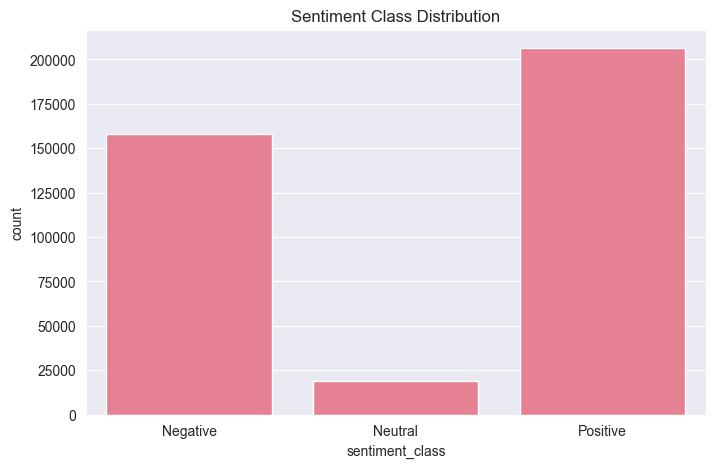

In [56]:
#Sentiment Imbalance Analysis
plt.figure(figsize=(8,5))
sns.countplot(x='sentiment_class', data=df)
plt.title('Sentiment Class Distribution')

<p>
This graph shows the sentiment classification, and a class imbalance was found. While positive and negative are relatively equal to each other, neutral sentiment is extremely low compared to the others, which is natural, considering this analysis is using consumer complaint data and most users submitting complaints would be expected to have negative sentiment, which is an assumption. This class imbalance is not necessarily bad, as the business requires an analysis and a model that handles the sentiment of many negative reviews, having positive data, a way for them to know where they are doing things right; however, it increases the chance of the model performing poorly in identifying neutral sentiment.
</p>

<h3>Positive and Negative Words</h3>

In [57]:
# Filter negative tokens
negative_tokens = df.loc[df['sentiment_class'] =='Negative', 'negation_tokens']
negative_words = []
# Loops through the negative tokens
for tokens in negative_tokens:
    if isinstance(tokens,list):
        negative_words.extend([w for w in tokens if len(w) > 2])
# Shows top 20 negative most common tokens 
negative_freqs = Counter(negative_words)
negative_freqs.most_common(20)

[('account', 233455),
 ('payment', 154362),
 ('debt', 150834),
 ('credit', 149092),
 ('loan', 112375),
 ('time', 98458),
 ('information', 98251),
 ('report', 98193),
 ('bank', 92616),
 ('company', 92285),
 ('did', 85494),
 ('told', 85133),
 ('received', 77585),
 ('letter', 75571),
 ('called', 71640),
 ('day', 70910),
 ('pay', 65554),
 ('sent', 63353),
 ('collection', 61680),
 ('month', 57738)]

In [58]:
# Filter negative tokens
positive_tokens = df.loc[df['sentiment_class'] =='Positive', 'negation_tokens']
positive_words = []
# Loops through the negative tokens
for tokens in positive_tokens:
    if isinstance(tokens,list):
        positive_words.extend([w for w in tokens if len(w) > 2])
# Shows top 20 negative most common tokens 
positive_freqs = Counter(positive_words)
positive_freqs.most_common(20)

[('credit', 429067),
 ('account', 335748),
 ('payment', 239656),
 ('loan', 191257),
 ('report', 183151),
 ('time', 132058),
 ('information', 129980),
 ('card', 123101),
 ('bank', 117431),
 ('did', 114670),
 ('told', 110523),
 ('company', 109345),
 ('received', 103016),
 ('day', 95104),
 ('month', 90010),
 ('letter', 88365),
 ('called', 87161),
 ('mortgage', 80807),
 ('year', 80159),
 ('sent', 76406)]

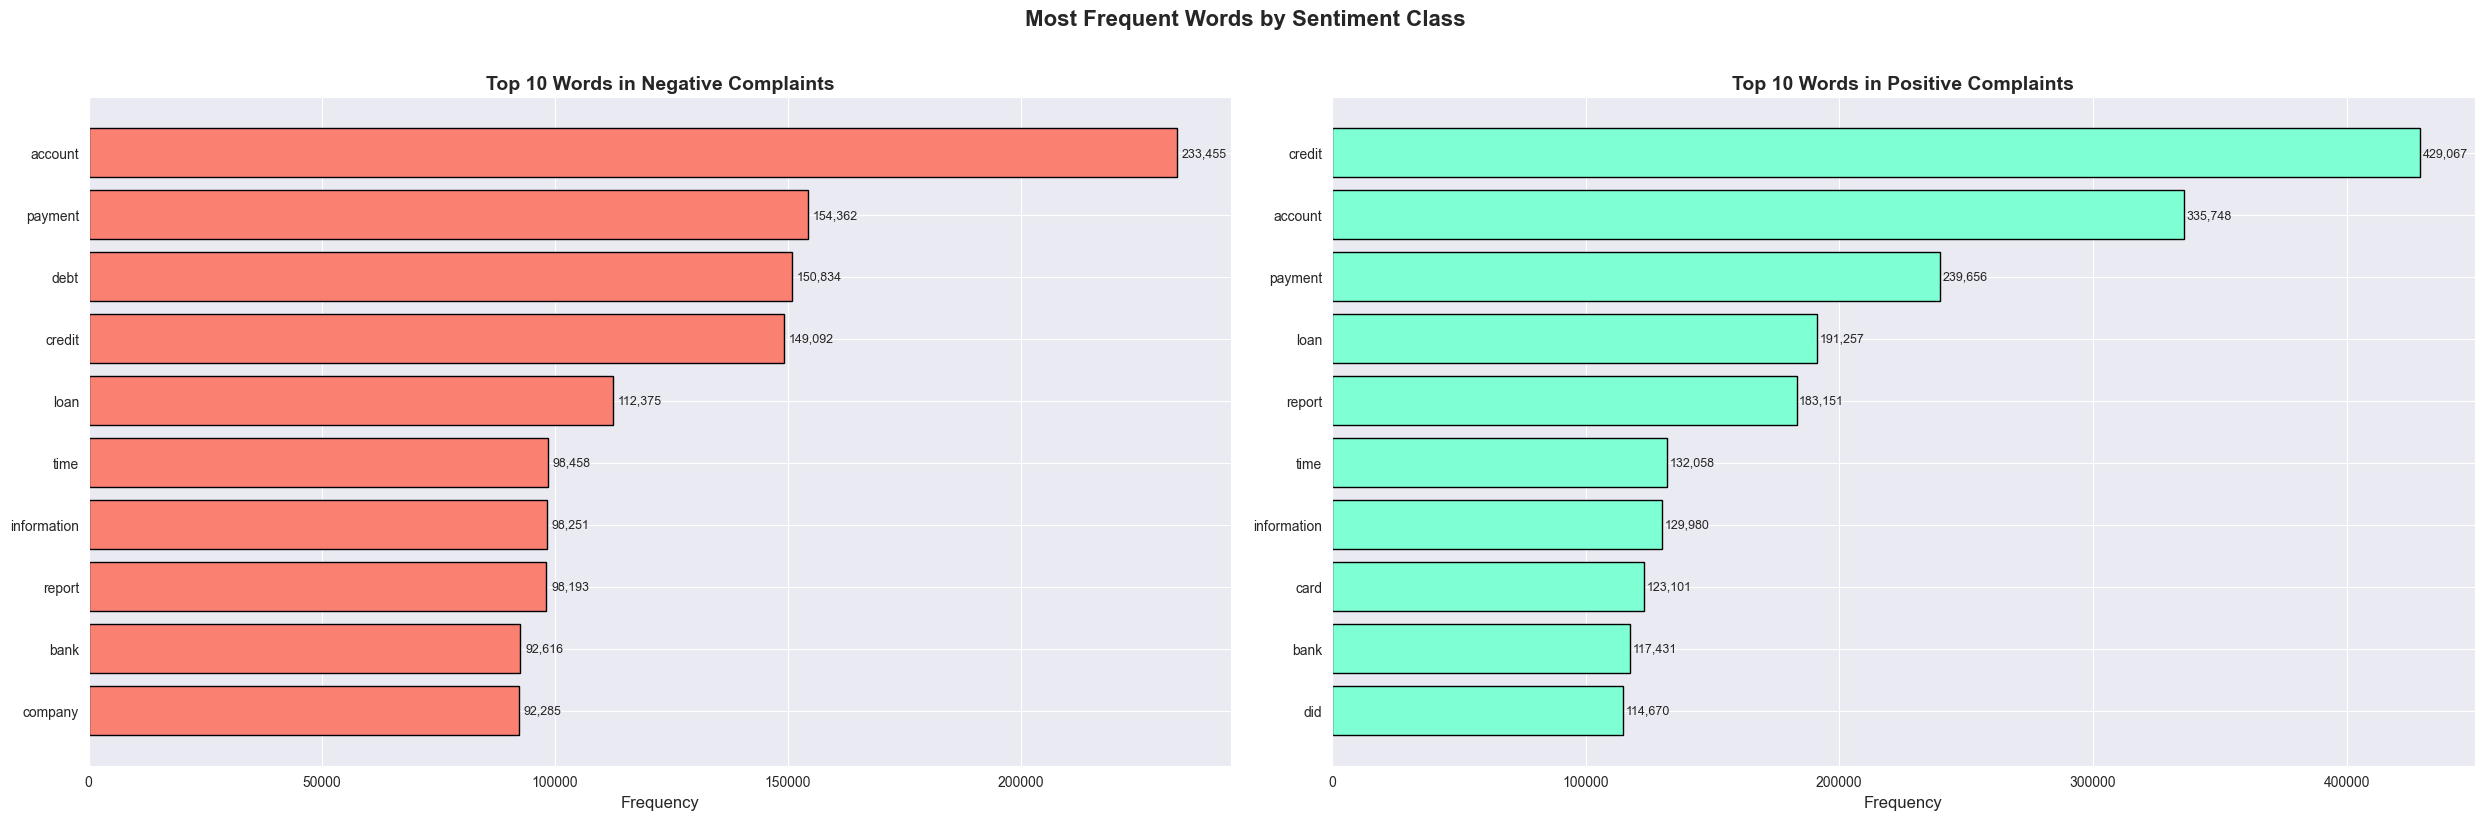

In [59]:
# Create side by side bar plot
fig, axes = plt.subplots(1,2, figsize=(25,8))
#Negative words plot
neg_words, neg_counts = zip(*negative_freqs.most_common(10))
axes[0].barh(neg_words, neg_counts, color='salmon', edgecolor='black', linewidth=1)
axes[0].set_title('Top 10 Words in Negative Complaints', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency', fontsize=12)
axes[0].invert_yaxis()
# Adds value lavels
for i, count in enumerate(neg_counts):
    axes[0].text(count + 1000, i, f'{count:,}', va='center', fontsize=9)

#Positive words plot
pos_words, pos_counts = zip(*positive_freqs.most_common(10))
axes[1].barh(pos_words, pos_counts, color='aquamarine', edgecolor='black', linewidth=1)
axes[1].set_title('Top 10 Words in Positive Complaints', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].invert_yaxis()
# Adds value lavels
for i, count in enumerate(pos_counts):
    axes[1].text(count + 1000, i, f'{count:,}', va='center', fontsize=9)

plt.suptitle('Most Frequent Words by Sentiment Class', fontsize=16,fontweight='bold',y=1.02)
plt.tight_layout()
plt.show()

<p>
The 10 most common positive words in positive complaints are: credit, account, loan, report, time, information, card, bank and did, while for negative complaints are: account, payment, debt, credit, loan, time, information, report, bank and company. It is possible to see that some of the same words can be found in a type of complaint, which is expected since the complaints are based on the financial sector, which means that for the medical aid, the same healthcare-related terms might be among the positive and negative complaints.
</p>

<h3>N-GRAMS</h3>

In [60]:
# N-Grams
# Get top n-grams from text series
def get_grams(token_column, n, top_k=20,):
    # cleain text
    text_series = token_column.apply(lambda x: ' '.join(x) if isinstance(x, list) else '')

    #Vectorized to Get n-grams
    vectorizer = CountVectorizer(ngram_range=(n,n), min_df=1)
    ngram_matrix = vectorizer.fit_transform(text_series)
    ngram_counts = np.array(ngram_matrix.sum(axis=0)).flatten()

    # Get top n-grams
    feature_names = vectorizer.get_feature_names_out()
    ngram_freq = pd.DataFrame({'ngram':feature_names,'count':ngram_counts}).sort_values('count',ascending=False).head(top_k)
    return ngram_freq


In [61]:
print('Top 20 Unigrams')
unigrams = get_grams(df['negation_tokens'], n=1, top_k=20)
print(unigrams)

Top 20 Unigrams
              ngram   count
103779           wa  999653
21688        credit  587137
806         account  584367
71468       payment  403596
51781          loan  311131
81430        report  287958
96462          time  235671
45548   information  233197
39949            ha  232184
23365          debt  217294
9579           bank  214840
18234       company  206775
25877           did  204439
97014          told  199581
78545      received  184980
14137          card  182895
23040           day  169892
50805        letter  167673
13645        called  162235
56077         month  151035


In [62]:
print('Top 20 Bigrams')
bigrams = get_grams(df['negation_tokens'], n=2, top_k=20)
print(bigrams)

Top 20 Bigrams
                     ngram   count
910088       credit report  167915
906018         credit card   78893
4037127            wa told   71077
905903       credit bureau   55480
39259           account wa   53451
910113    credit reporting   38434
936909    customer service   33398
2715970         payment wa   33357
910462        credit score   30706
362141        bank america   29619
692561   collection agency   29444
3176511   reporting agency   26958
3616000       student loan   26924
2036853       late payment   26664
2152053            loan wa   25765
1790335     identity theft   24806
2211417       make payment   22872
621889    checking account   22450
2035936           late fee   21374
3033066    received letter   21200


In [63]:
print('Top 20 Trigrams')
trigrams = get_grams(df['negation_tokens'], n=3, top_k=20)
print(trigrams)

Top 20 Trigrams
                                  ngram  count
3621040         credit reporting agency  16468
5356583           fair credit reporting  12146
3620990            credit reporting act  11996
13425534         social security number  10362
11981112          removed credit report   9332
137788            account credit report   8598
15611970                     wa told wa   7672
3194329       consumer reporting agency   7645
15239864          victim identity theft   7418
7127476       information credit report   7361
3963635        debt collection practice   7244
5356779            fair debt collection   7086
2776082         collection practice act   6607
3560566             credit card account   6561
3561283             credit card company   6063
271756                account wa closed   5532
3620521                credit report wa   5492
7258278           inquiry credit report   5035
3377319              copy credit report   4605
3184629   consumer financial protection   45

In [64]:
# Calculate top 10 
uni = unigrams.head(10)
bi = bigrams.head(10)
tri = trigrams.head(10)

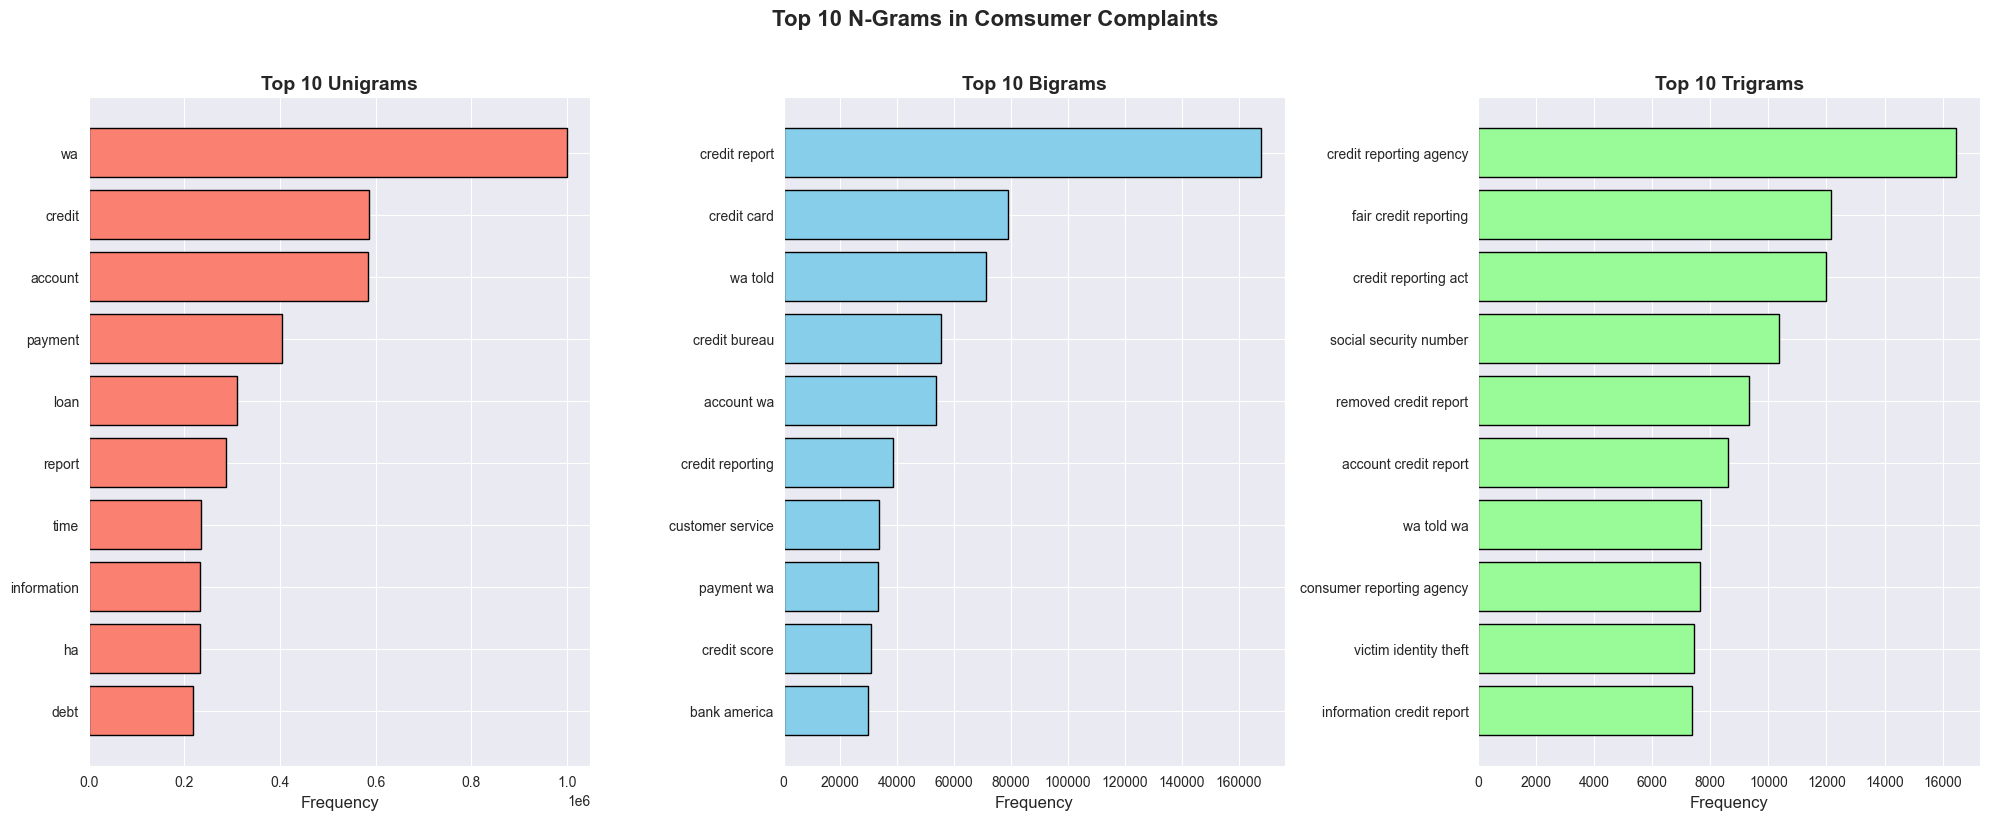

In [65]:
# Create side by side bar plot
fig, axes = plt.subplots(1,3, figsize=(20,8))

#Unigram plot
uni_words = uni['ngram'].values
uni_counts = uni['count'].values
bars1 = axes[0].barh(uni_words, uni_counts, color='salmon', edgecolor='black', linewidth=1)
axes[0].set_title('Top 10 Unigrams', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency', fontsize=12)
axes[0].invert_yaxis()

#Bigram Plot
bi_words = bi['ngram'].values
bi_counts = bi['count'].values
bars2 = axes[1].barh(bi_words, bi_counts, color='skyblue', edgecolor='black', linewidth=1)
axes[1].set_title('Top 10 Bigrams', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].invert_yaxis()

#Trigram Plot
tri_words = tri['ngram'].values
tri_counts = tri['count'].values
bars3 = axes[2].barh(tri_words, tri_counts, color='palegreen', edgecolor='black', linewidth=1)
axes[2].set_title('Top 10 Trigrams', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Frequency', fontsize=12)
axes[2].invert_yaxis()

plt.suptitle('Top 10 N-Grams in Comsumer Complaints', fontsize=16,fontweight='bold',y=1.02)
plt.tight_layout()
plt.show()

<p>
The top 10 unigram graphs have the same distribution as the top 10-word graphs, indicating the n-gram analysis is correct.

The bigram graphs show the top 10 two-word phrases that appear most frequently together, such as: credit report, credit card, was told, and others were found. Most of the information found in the graph is related to financial terms, except the was told term, which indicates that many users' complaints include something related to a company’s guide or information, and it was not an error they committed without guidance.

Looking on the top trigrams, the most recurring 3 words are credit reporting agency, fair credit reporting, and credit reporting act, indicating that most complaints are about credit-related issues, which seems to be true when looking at the distribution of credit report in bigrams, which has a higher frequency compared to other terms. Another insight that can be taken from the unigrams graph is the fact that most consumers indeed report issues of their own, since the term “was” has the highest frequency among the words, and this word is also frequently associated with “told”, “payment” and “account”.

</p>

<h3>Topic Modelling (LDA)</h3>

In [66]:
# Vectorising negation_text for top modellig
vectorizer_lda = CountVectorizer(max_features=1000, max_df=0.7, min_df=1, ngram_range=(1,2))
vector = vectorizer_lda.fit_transform(df_sample['negation_text'])
vector_names = vectorizer_lda.get_feature_names_out()

In [67]:
#using the vectorizer matrix to fit LDA
lda = LatentDirichletAllocation(n_components=5,random_state=42, max_iter=20, learning_method='batch')
lda.fit(vector)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",20
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [68]:
# Display   LDA top words based and their scores
def display_top_topics(model, feature_names, num_words=5):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-num_words-1:1]]
        top_scores = [topic[i] for i in topic.argsort()[:-num_words-1:1]]
        
        topics[f'Topic {topic_idx+1}'] = top_words
        print(f'\nTopic {topic_idx+1}: ')
        for word, score in zip(top_words, top_scores):
            print(f'   {word:15}: {score:.4f}')

    return topics

display_top_topics(lda, vector_names)


Topic 1: 
   consumer reporting: 0.2001
   inquiry inquiry: 0.2001
   shall          : 0.2004
   reporting act  : 0.2005
   fair credit    : 0.2006
   victim identity: 0.2007
   overdraft fee  : 0.2007
   identity theft : 0.2008
   hard inquiry   : 0.2009
   sl             : 0.2009
   reporting agency: 0.2009
   inquiry credit : 0.2010
   overdraft      : 0.2010
   card account   : 0.2010
   public record  : 0.2010
   promotion      : 0.2010
   american express: 0.2011
   credit limit   : 0.2012
   forgiveness    : 0.2012
   practice act   : 0.2013
   fcra           : 0.2013
   alleged debt   : 0.2013
   servicer       : 0.2013
   borrower       : 0.2013
   credit file    : 0.2013
   report account : 0.2014
   inquiry        : 0.2014
   nationstar     : 0.2014
   bank america   : 0.2015
   theft          : 0.2015
   merchant       : 0.2016
   loan modification: 0.2016
   credit reporting: 0.2016
   payment history: 0.2016
   reward         : 0.2016
   equifax        : 0.2017
   accoun

{'Topic 1': ['consumer reporting',
  'inquiry inquiry',
  'shall',
  'reporting act',
  'fair credit',
  'victim identity',
  'overdraft fee',
  'identity theft',
  'hard inquiry',
  'sl',
  'reporting agency',
  'inquiry credit',
  'overdraft',
  'card account',
  'public record',
  'promotion',
  'american express',
  'credit limit',
  'forgiveness',
  'practice act',
  'fcra',
  'alleged debt',
  'servicer',
  'borrower',
  'credit file',
  'report account',
  'inquiry',
  'nationstar',
  'bank america',
  'theft',
  'merchant',
  'loan modification',
  'credit reporting',
  'payment history',
  'reward',
  'equifax',
  'account removed',
  'copy credit',
  'paypal',
  'usc',
  'information credit',
  'validation',
  'original creditor',
  'chase bank',
  'repayment plan',
  'fair debt',
  'inquires',
  'mortgage loan',
  'foreclosure',
  'modification',
  'short sale',
  'reporting credit',
  'experian',
  'collection account',
  'ditech',
  'identity',
  'student loan',
  'transun

In [69]:
# transforming lda to ndarray due to pyLADvis requirement
doc_topic_dists = lda.transform(vector)

In [70]:
# Get document-topic distribution
term_freq = np.array(vector.sum(axis=0)).flatten()
topic_term_dists = lda.components_/ lda.components_.sum(axis=1)[:,np.newaxis]
# Prepare the visualization
panel = pyLDAvis.prepare(vocab=vector_names,
                         doc_topic_dists=doc_topic_dists,
                         doc_lengths=np.array([len(doc.split()) for doc in df_sample['negation_text']]),
                         mds='tsne',
                         sort_topics='True', 
                         topic_term_dists=topic_term_dists,
                         term_frequency=term_freq)

#Display the visualization on the browser
#pyLADvis.display(panel)
pyLDAvis.display(panel)

<p>
The left part of the graphic, the intertopic distance map, allows us to visualise how similar or different the discovered topics are from one another, it is possible to see that topics 1-2 and 3-4 are parallel to each other, and topic 3-5 are the closest. The graph on the right allows us to see the comparison of the word frequency within a specific topic compared to the total frequency.

In terms of token%, meaning the percentage of different words per topic that would be classified as: 

•	Topic – 25.8%

•	Topic 2 – 22.9%

•	Topic 3 – 21%

•	Topic 4 – 17.9%

•	Topic 5 – 12.4%

Meaning the top 3 topics have the highest number of different tokens.
</p>


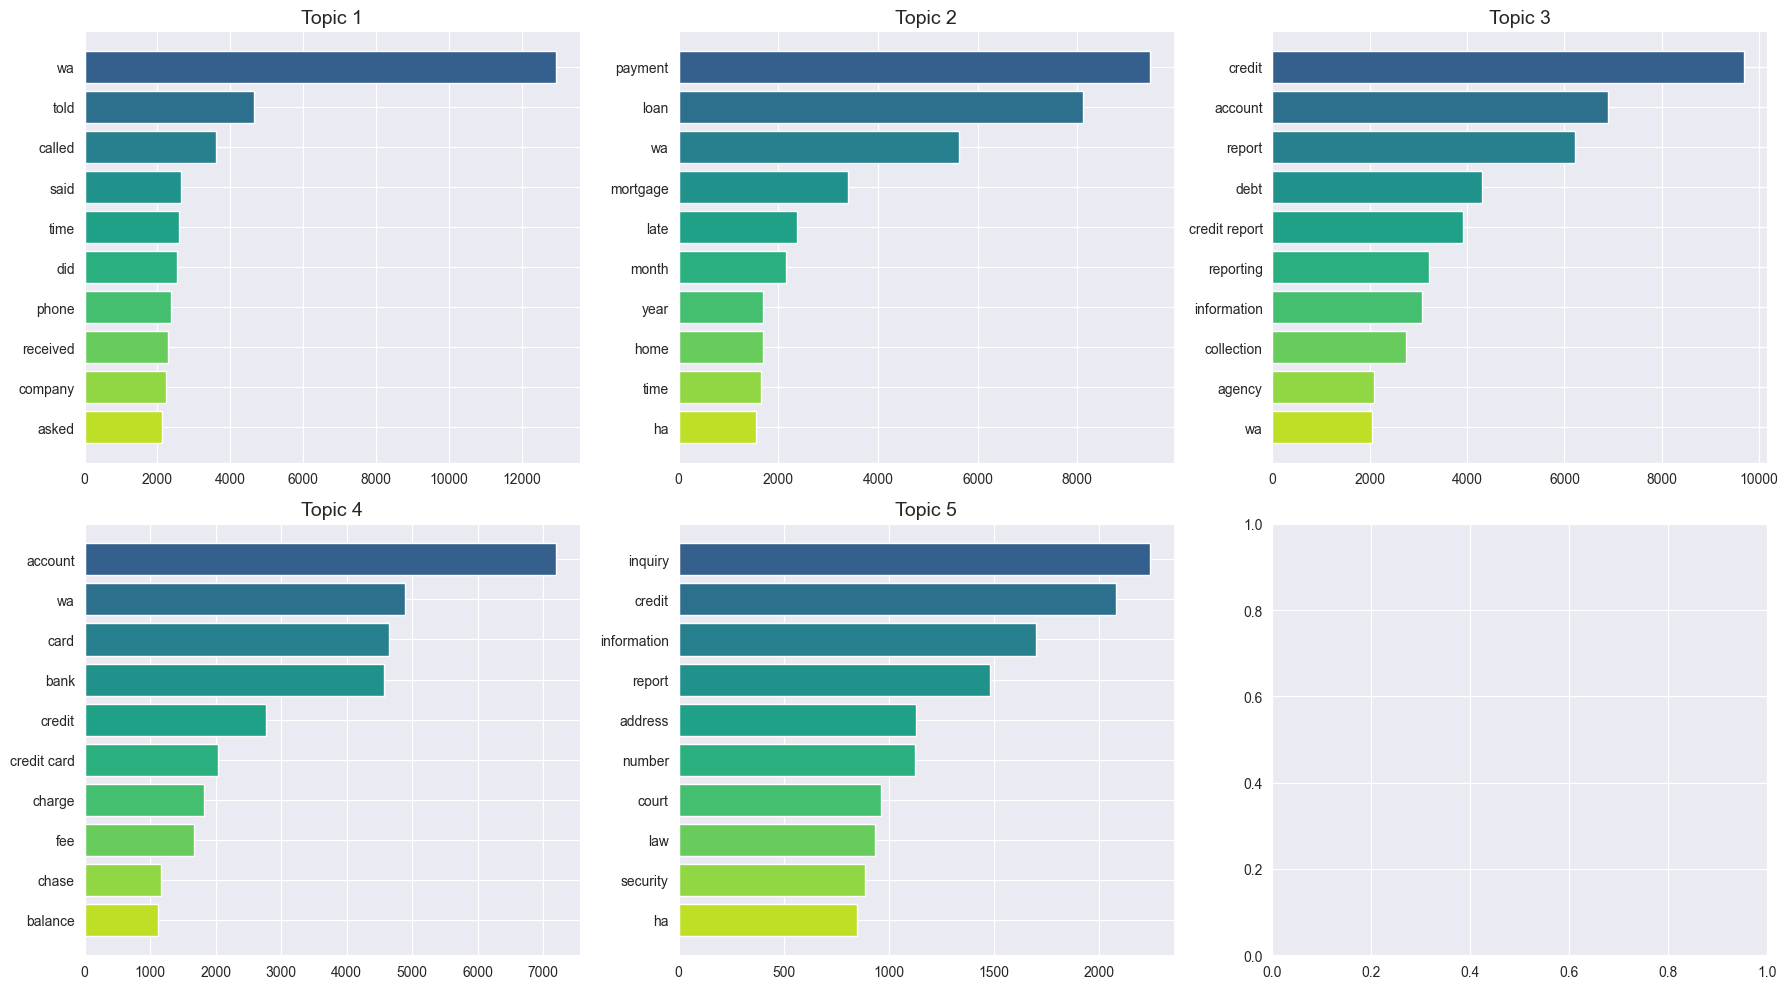

In [71]:
# Function to display top words for each topic
def display_topics(model, feature_names,no_top_words=10):
    fig, axes = plt.subplots(2,3, figsize=(18,10))
    axes = axes.flatten()

    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[-no_top_words:][::-1]
        top_words = [feature_names[i] for i in top_words_idx]
        top_weights = [topic[i] for i in top_words_idx]

        # Bar chart
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, no_top_words))
        axes[topic_idx].barh(top_words, top_weights, color=colors)
        axes[topic_idx].set_title(f'Topic {topic_idx + 1}', fontsize=14)
        axes[topic_idx].invert_yaxis()

    plt.tight_layout()
    plt.show()

display_topics(lda, vector_names)

Based on the first Topic Modelling solely, the main areas of concern can be described as follows:
•	Topic 1: Communication Issues

•	Topic 2: Loans, mortgages, and payments

•	Topic 3: Credit reporting and debt disputes

•	Topic 4: Banking and credit card charges

•	Topic 5: Credit inquiries and security


<h3>TF-IDF</h3>

In [72]:
#TF IDF
tfid_vect = TfidfVectorizer(max_features=1000,min_df=5,max_df=0.7, ngram_range=(1,3))
tfid_matrix = tfid_vect.fit_transform(df['negation_text'])
feature_names = tfid_vect.get_feature_names_out()

In [73]:
tfid_matrix.shape

(383541, 1000)

In [74]:
len(feature_names)

1000

In [75]:
#Getting average TF-IDF score for each word
avg_tfid = np.array(tfid_matrix.mean(axis=0)).flatten()
tfidf_df = pd.DataFrame({
    'word': feature_names,
    'avg_tfidf': avg_tfid
}).sort_values('avg_tfidf',ascending=False)

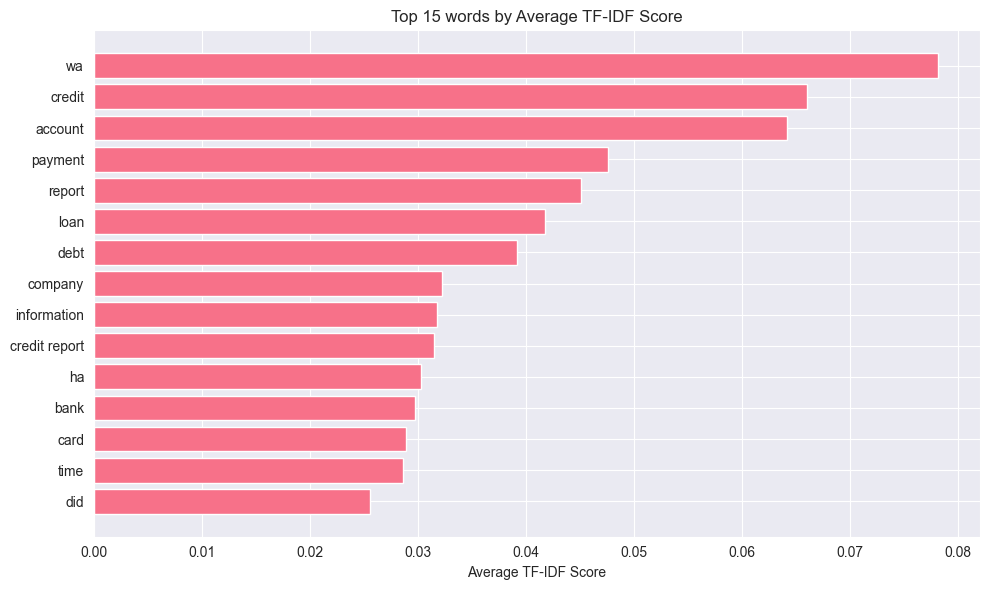

In [76]:
# Display Barh chart of top 15 words and their score
plt.figure(figsize=(10,6))
top_tfidf = tfidf_df.head(15)
plt.barh(top_tfidf['word'], top_tfidf['avg_tfidf'])
plt.gca().invert_yaxis()
plt.title('Top 15 words by Average TF-IDF Score')
plt.xlabel('Average TF-IDF Score')
plt.tight_layout()
plt.show()

<p>
The TF-IDF score indicates that a word appears frequently where it is important, is more distinct than generic words and helps differentiate complaints from one another.

“wa” having the highest score is surprising since and not meaningful, on the other hand, credit and account being the second highest indicates that the credit and account-related matters are a dominant theme within customer complaints and play an important role in distinguishing complaint context and with the report having the 4th highest score reminds us the fact that trigrams analysis indicates that these 3 words are among the most frequently combination of words and now the TF-IDF shows us that all of them play an import role within this analysis and are at the core of the consumer complaints.

</p>

<h3>Topic Modelling (LDA + TF-IDF)</h3>

In [77]:
#tfid_matrix_sample = tfid_matrix.sample(10000, random_state=42)
sample_idx = np.random.RandomState(42).choice(tfid_matrix.shape[0],size=10000, replace=False)
tfid_matrix_sample = tfid_matrix[sample_idx]

In [78]:
lda_tfidf = LatentDirichletAllocation(n_components=5,random_state=42, max_iter=20, learning_method='batch', learning_offset=50, doc_topic_prior=0.1, topic_word_prior=0.01)
lda_tfidf.fit(tfid_matrix_sample)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",0.1
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",0.01
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",50
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",20
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [79]:
display_top_topics(lda_tfidf, feature_names)


Topic 1: 
   affidavit      : 0.0100
   debt collector : 0.0100
   debt collection practice: 0.0100
   atm            : 0.0100
   merchant       : 0.0100
   credit reporting act: 0.0100
   certified letter: 0.0100
   original creditor: 0.0100
   alleged        : 0.0100
   alleged debt   : 0.0100
   shall          : 0.0100
   consumer reporting agency: 0.0100
   consumer reporting: 0.0100
   overdraft fee  : 0.0100
   american express: 0.0100
   amex           : 0.0100
   compliance     : 0.0100
   personal information: 0.0100
   pnc            : 0.0100
   public record  : 0.0100
   police report  : 0.0100
   collection practice act: 0.0100
   collection practice: 0.0100
   collection account: 0.0100
   theft          : 0.0100
   appraisal      : 0.0100
   coinbase       : 0.0100
   practice act   : 0.0100
   deed           : 0.0100
   reporting act  : 0.0100
   chase bank     : 0.0100
   identity       : 0.0100
   freeze         : 0.0100
   ftc            : 0.0100
   hard inquiry   : 

{'Topic 1': ['affidavit',
  'debt collector',
  'debt collection practice',
  'atm',
  'merchant',
  'credit reporting act',
  'certified letter',
  'original creditor',
  'alleged',
  'alleged debt',
  'shall',
  'consumer reporting agency',
  'consumer reporting',
  'overdraft fee',
  'american express',
  'amex',
  'compliance',
  'personal information',
  'pnc',
  'public record',
  'police report',
  'collection practice act',
  'collection practice',
  'collection account',
  'theft',
  'appraisal',
  'coinbase',
  'practice act',
  'deed',
  'reporting act',
  'chase bank',
  'identity',
  'freeze',
  'ftc',
  'hard inquiry',
  'fair debt collection',
  'fair debt',
  'fair credit reporting',
  'security number',
  'validate',
  'fdcpa',
  'identity theft',
  'victim identity theft',
  'violated',
  'victim identity',
  'breach',
  'validation',
  'bonus',
  'boa',
  'social security number',
  'belong',
  'block',
  'reward',
  'judgement',
  'inquiry credit',
  'inquires',
  '

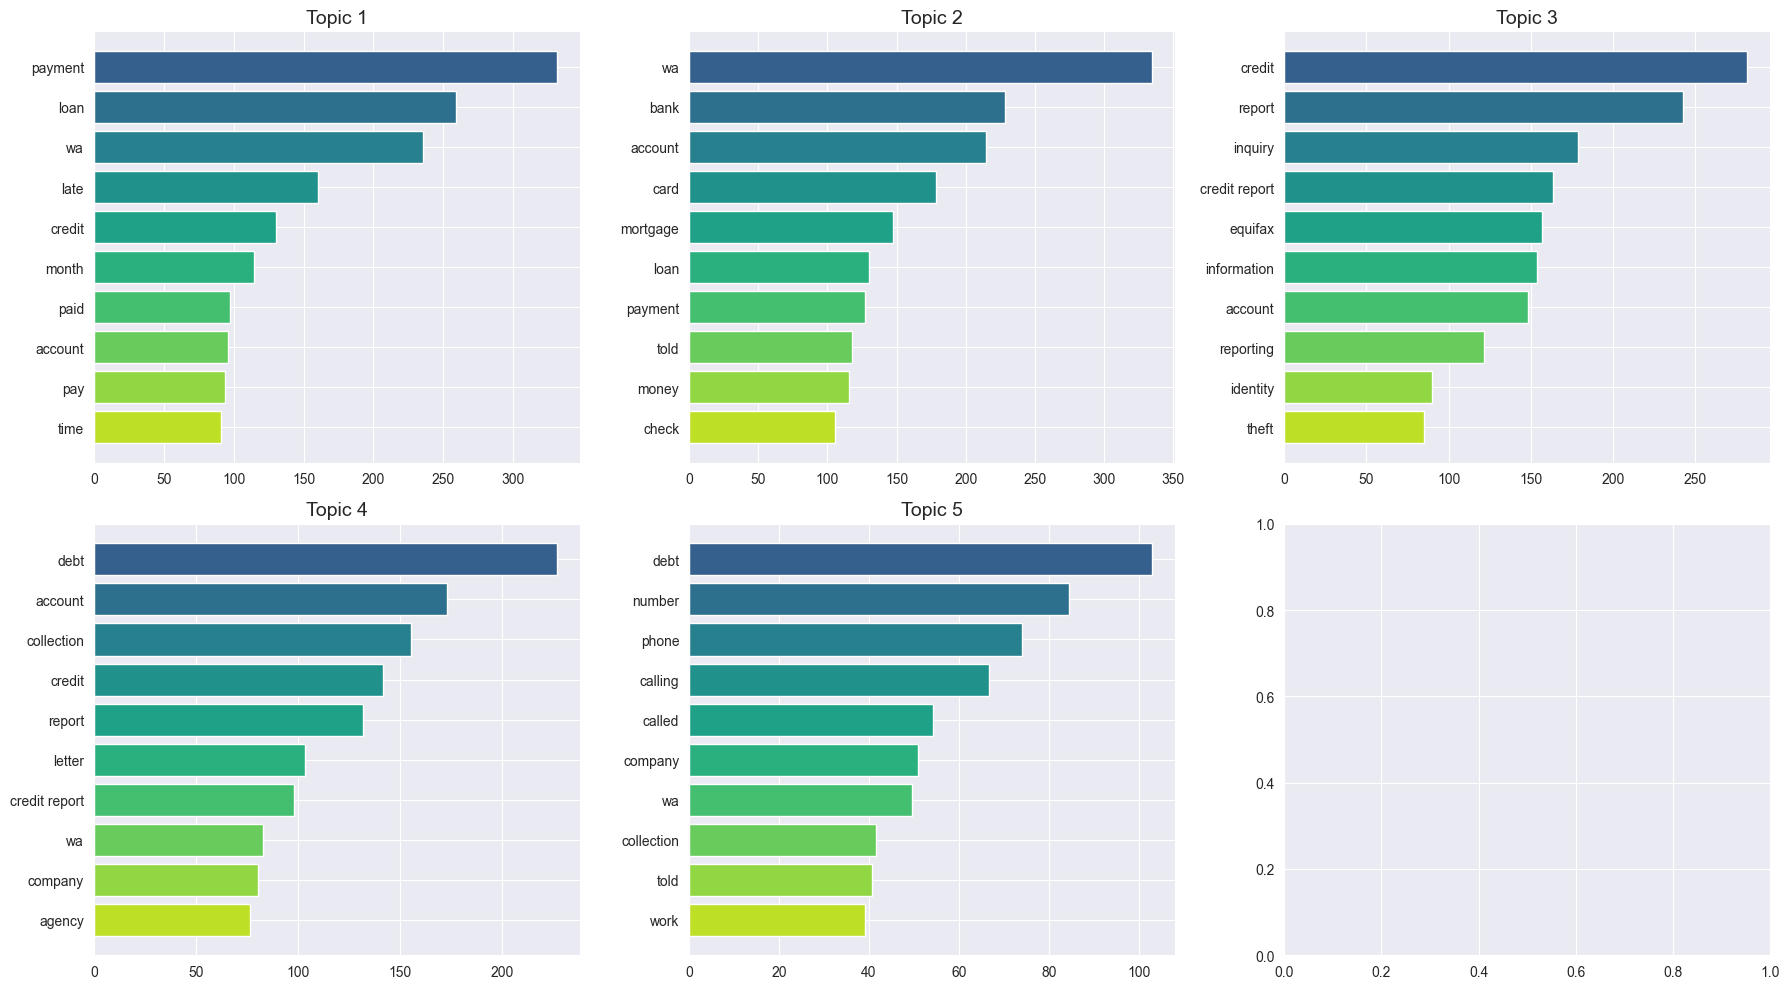

In [80]:
display_topics(lda_tfidf, feature_names)

<p>
The topics and distribution seem to be similar to those found by just LDA, and since both methods discovered the same details, it increases the reliability of the findings.
</p>

<h2>Modelling and Evaluation.</h2>

In [81]:
# Selecting the variables to train the models
X = tfid_matrix
Y = df['sentiment_class']

In [82]:
#Splitting the X and Y, 80% for training and the rest for testing
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42, stratify=Y)

In [83]:
# Training the Logistic Regression Model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, Y_train)
y_pred = lr.predict(X_test)
# Calculates and Display Model Performance
print(f'Accuracy Score: {accuracy_score(Y_test,y_pred)}')
print(classification_report(Y_test,y_pred))

Accuracy Score: 0.8510865739352619
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.84     31615
     Neutral       0.81      0.37      0.51      3814
    Positive       0.86      0.90      0.88     41280

    accuracy                           0.85     76709
   macro avg       0.84      0.70      0.74     76709
weighted avg       0.85      0.85      0.85     76709



In [84]:
# Training the Multinomial Naive Bayes  Model
mnb = MultinomialNB()
mnb.fit(X_train, Y_train)
y_pred = mnb.predict(X_test)
# Calculates and Display Model Performance
print(f'Accuracy Score: {accuracy_score(Y_test,y_pred)}')
print(classification_report(Y_test,y_pred))

Accuracy Score: 0.7063838662999127


C:\Users\Alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    Negative       0.75      0.56      0.64     31615
     Neutral       0.00      0.00      0.00      3814
    Positive       0.69      0.88      0.77     41280

    accuracy                           0.71     76709
   macro avg       0.48      0.48      0.47     76709
weighted avg       0.68      0.71      0.68     76709



C:\Users\Alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<p>
The overall performance of the Logistic Regression (0.85) shows a higher accuracy, correctly classifying a larger proportion of complaints, indicating a good generalisation to unseen data. Additionally, it also shows a consistent performance classifying negative (0.84) and positive (0.86) classes while showing a moderate performance on neutral (0.51), thus this model will be selected as the final model.

Now that the final model has been selected, a Hyperparameter tuning must be implemented to test if the model can be improved.

</p>

In [85]:
# Define Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])
#Hyperparameter Grid
params_grid = {
    #TF-IDF paramets
    'tfidf__max_features': [1000, 3000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [1,5],
    'tfidf__max_df': [0.7, 0.9],

    # Logistic Regression Parameters
    'clf__C': [0.1, 1, 10],
    'clf__solver':['lbfgs'],
    'clf__class_weight':['balanced']
}

# K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search CV
grid_search = GridSearchCV(estimator=pipeline, param_grid=params_grid,cv=cv,scoring='accuracy',n_jobs=1,verbose=2)
grid_search.fit(df['negation_text'],Y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__solver=lbfgs, tfidf__max_df=0.7, tfidf__max_features=1000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=  49.9s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__solver=lbfgs, tfidf__max_df=0.7, tfidf__max_features=1000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=  44.8s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__solver=lbfgs, tfidf__max_df=0.7, tfidf__max_features=1000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=  47.8s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__solver=lbfgs, tfidf__max_df=0.7, tfidf__max_features=1000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=  45.0s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__solver=lbfgs, tfidf__max_df=0.7, tfidf__max_features=1000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=  46.9s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__solv

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.1, 1, ...], 'clf__class_weight': ['balanced'], 'clf__solver': ['lbfgs'], 'tfidf__max_df': [0.7, 0.9], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

In [86]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(df['negation_text'])

In [87]:
print(f'Accuracy_score {accuracy_score(df['sentiment_class'], y_pred)}')
print(classification_report(df['sentiment_class'],y_pred))

Accuracy_score 0.890642721377897
              precision    recall  f1-score   support

    Negative       0.96      0.89      0.92    158072
     Neutral       0.36      0.90      0.51     19070
    Positive       0.97      0.89      0.93    206399

    accuracy                           0.89    383541
   macro avg       0.76      0.89      0.79    383541
weighted avg       0.94      0.89      0.91    383541



The new model shows a significant improvement over the baseline, with accuracy rising from 85% to 89%. Since the weighted average F1-Score increase from 85% to 91% it confirms the model's prediction are more reliable and well-rounded.

This most dramatic enchancement is in recall for neutral class, which jumped from 37% to 90%. Meaning the model went from missing nearly two-thirds of neutrl statements to correctly identifying the vast majority of them.

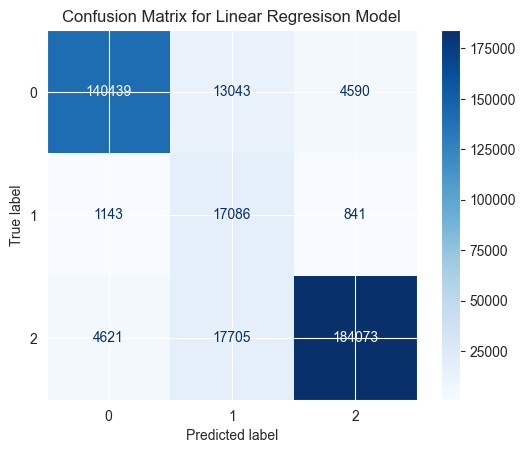

In [88]:
# Create confusion matrix
cm = confusion_matrix(df['sentiment_class'],y_pred)
#Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Linear Regresison Model")
plt.show()

<h2>Conclusion</h2>

<p>
The analysis successfully identified several areas of concern within consumer complaints, and the identification of these topics demonstrated how NLP techniques can automatically uncover recurring themes within large volumes of unstructured text, allowing organisations to focus their resources on the areas generating the highest levels of dissatisfaction.

Sentiment analysis further revealed the overall emotional tone of complaints, enabling complaints to be categorised into positive, neutral, and negative sentiment classes. Such information can help decision-makers monitor consumer satisfaction trends, identify emerging issues, and evaluate the effectiveness of corrective actions over time.
</p>